# EDA and Preprocessing for Air Quality Dataset

This notebook performs exploratory data analysis (EDA) on the Air Quality UCI dataset, splits the data into train and test sets, and finalizes preprocessing steps for use in Airflow orchestration.

In [4]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import joblib
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')

In [5]:
# Load Dataset from Root Folder
# The dataset is located in data/raw/AirQualityUCI.csv
df = pd.read_csv('data/raw/AirQualityUCI.csv', sep=';', decimal=',', na_values=-200)

# Remove the last two empty columns
df = df.iloc[:, :-2]

# Display basic info
print("Dataset shape:", df.shape)
print("\nColumns:", list(df.columns))
print("\nData types:")
print(df.dtypes)
print("\nFirst 5 rows:")
df.head()

Dataset shape: (9471, 15)

Columns: ['Date', 'Time', 'CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']

Data types:
Date              object
Time              object
CO(GT)           float64
PT08.S1(CO)      float64
NMHC(GT)         float64
C6H6(GT)         float64
PT08.S2(NMHC)    float64
NOx(GT)          float64
PT08.S3(NOx)     float64
NO2(GT)          float64
PT08.S4(NO2)     float64
PT08.S5(O3)      float64
T                float64
RH               float64
AH               float64
dtype: object

First 5 rows:


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888


In [6]:
# Split Dataset into Train and Test Sets
# First, let's assume the target is CO(GT) or we can choose based on EDA
# For air quality, we might predict multiple pollutants, but let's focus on CO(GT) for now

# Features and target
X = df.drop(['Date', 'Time', 'CO(GT)'], axis=1)  # Drop date/time and target
y = df['CO(GT)']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)  # Time series, so no shuffle

print("Train set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Train set shape: (7576, 12)
Test set shape: (1895, 12)


Missing values in training set:
PT08.S1(CO)       280
NMHC(GT)         6662
C6H6(GT)          280
PT08.S2(NMHC)     280
NOx(GT)          1585
PT08.S3(NOx)      280
NO2(GT)          1588
PT08.S4(NO2)      280
PT08.S5(O3)       280
T                 280
RH                280
AH                280
CO(GT)           1599
dtype: int64

Descriptive statistics:

Categorical columns: Index([], dtype='object')


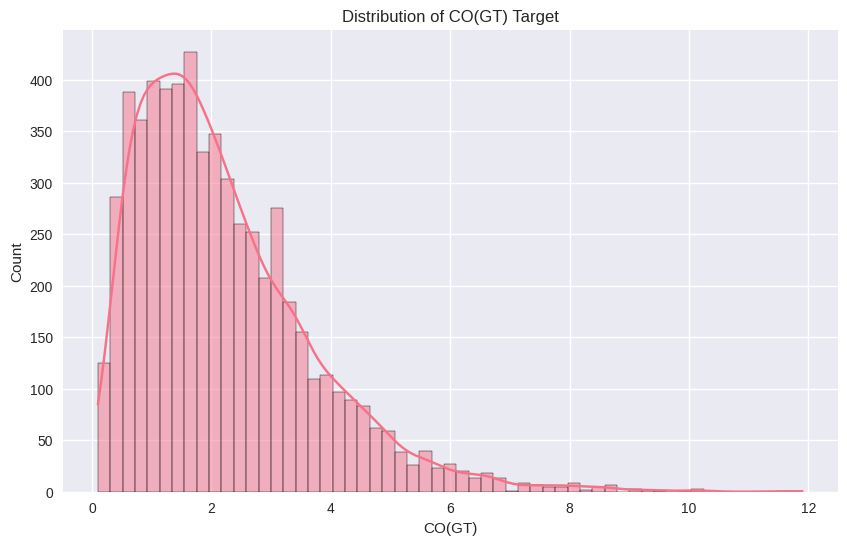

In [7]:
# Exploratory Data Analysis on Training Set
# Combine X_train and y_train for analysis
train_df = X_train.copy()
train_df['CO(GT)'] = y_train

print("Missing values in training set:")
print(train_df.isnull().sum())

print("\nDescriptive statistics:")
train_df.describe()

# Check for categorical features (though this dataset is mostly numerical)
categorical_cols = train_df.select_dtypes(include=['object']).columns
print("\nCategorical columns:", categorical_cols)

# Target distribution
plt.figure(figsize=(10, 6))
sns.histplot(y_train, kde=True)
plt.title('Distribution of CO(GT) Target')
plt.show()

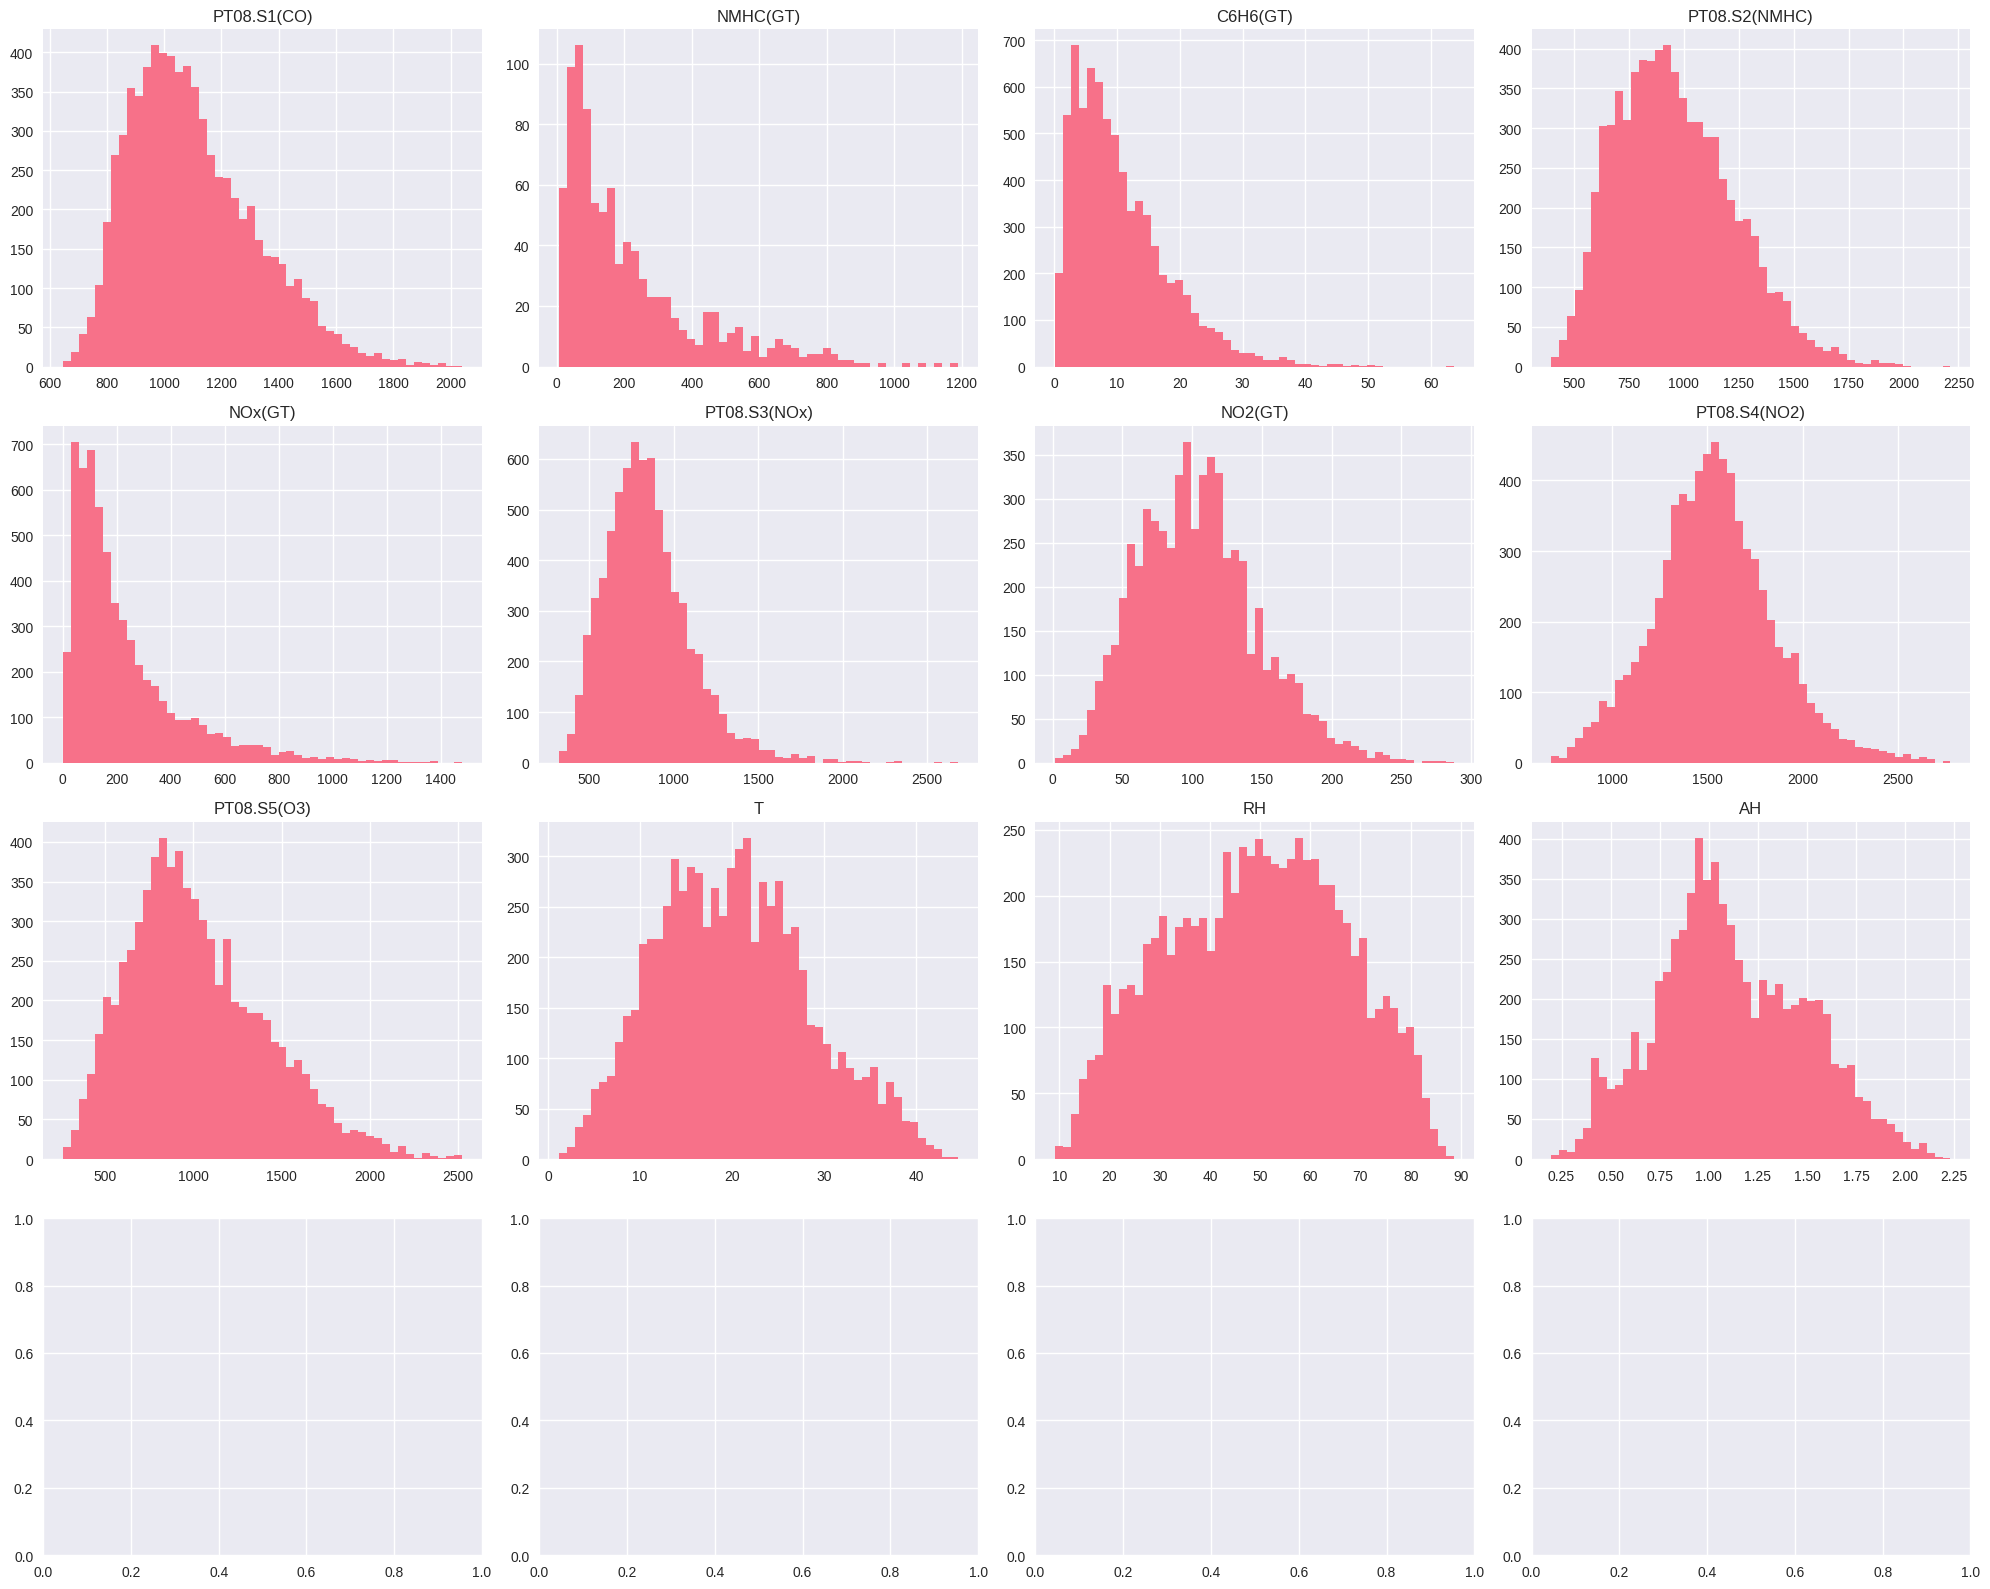

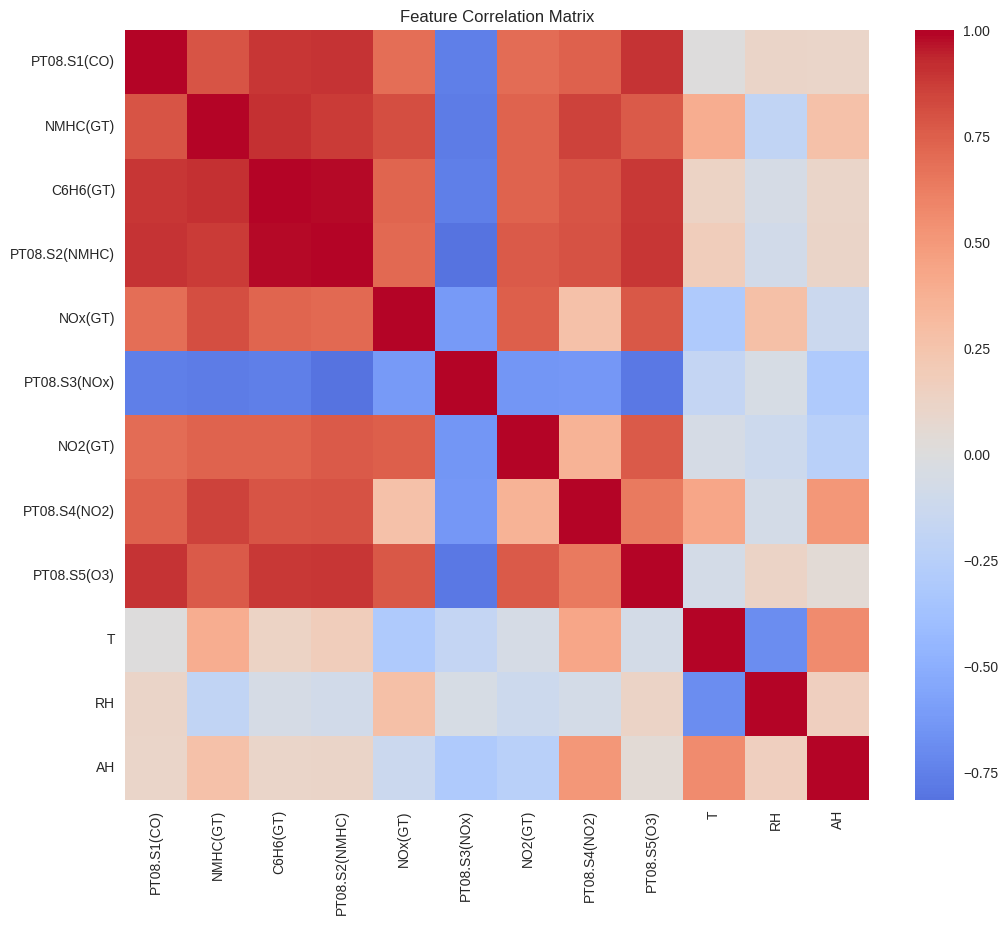

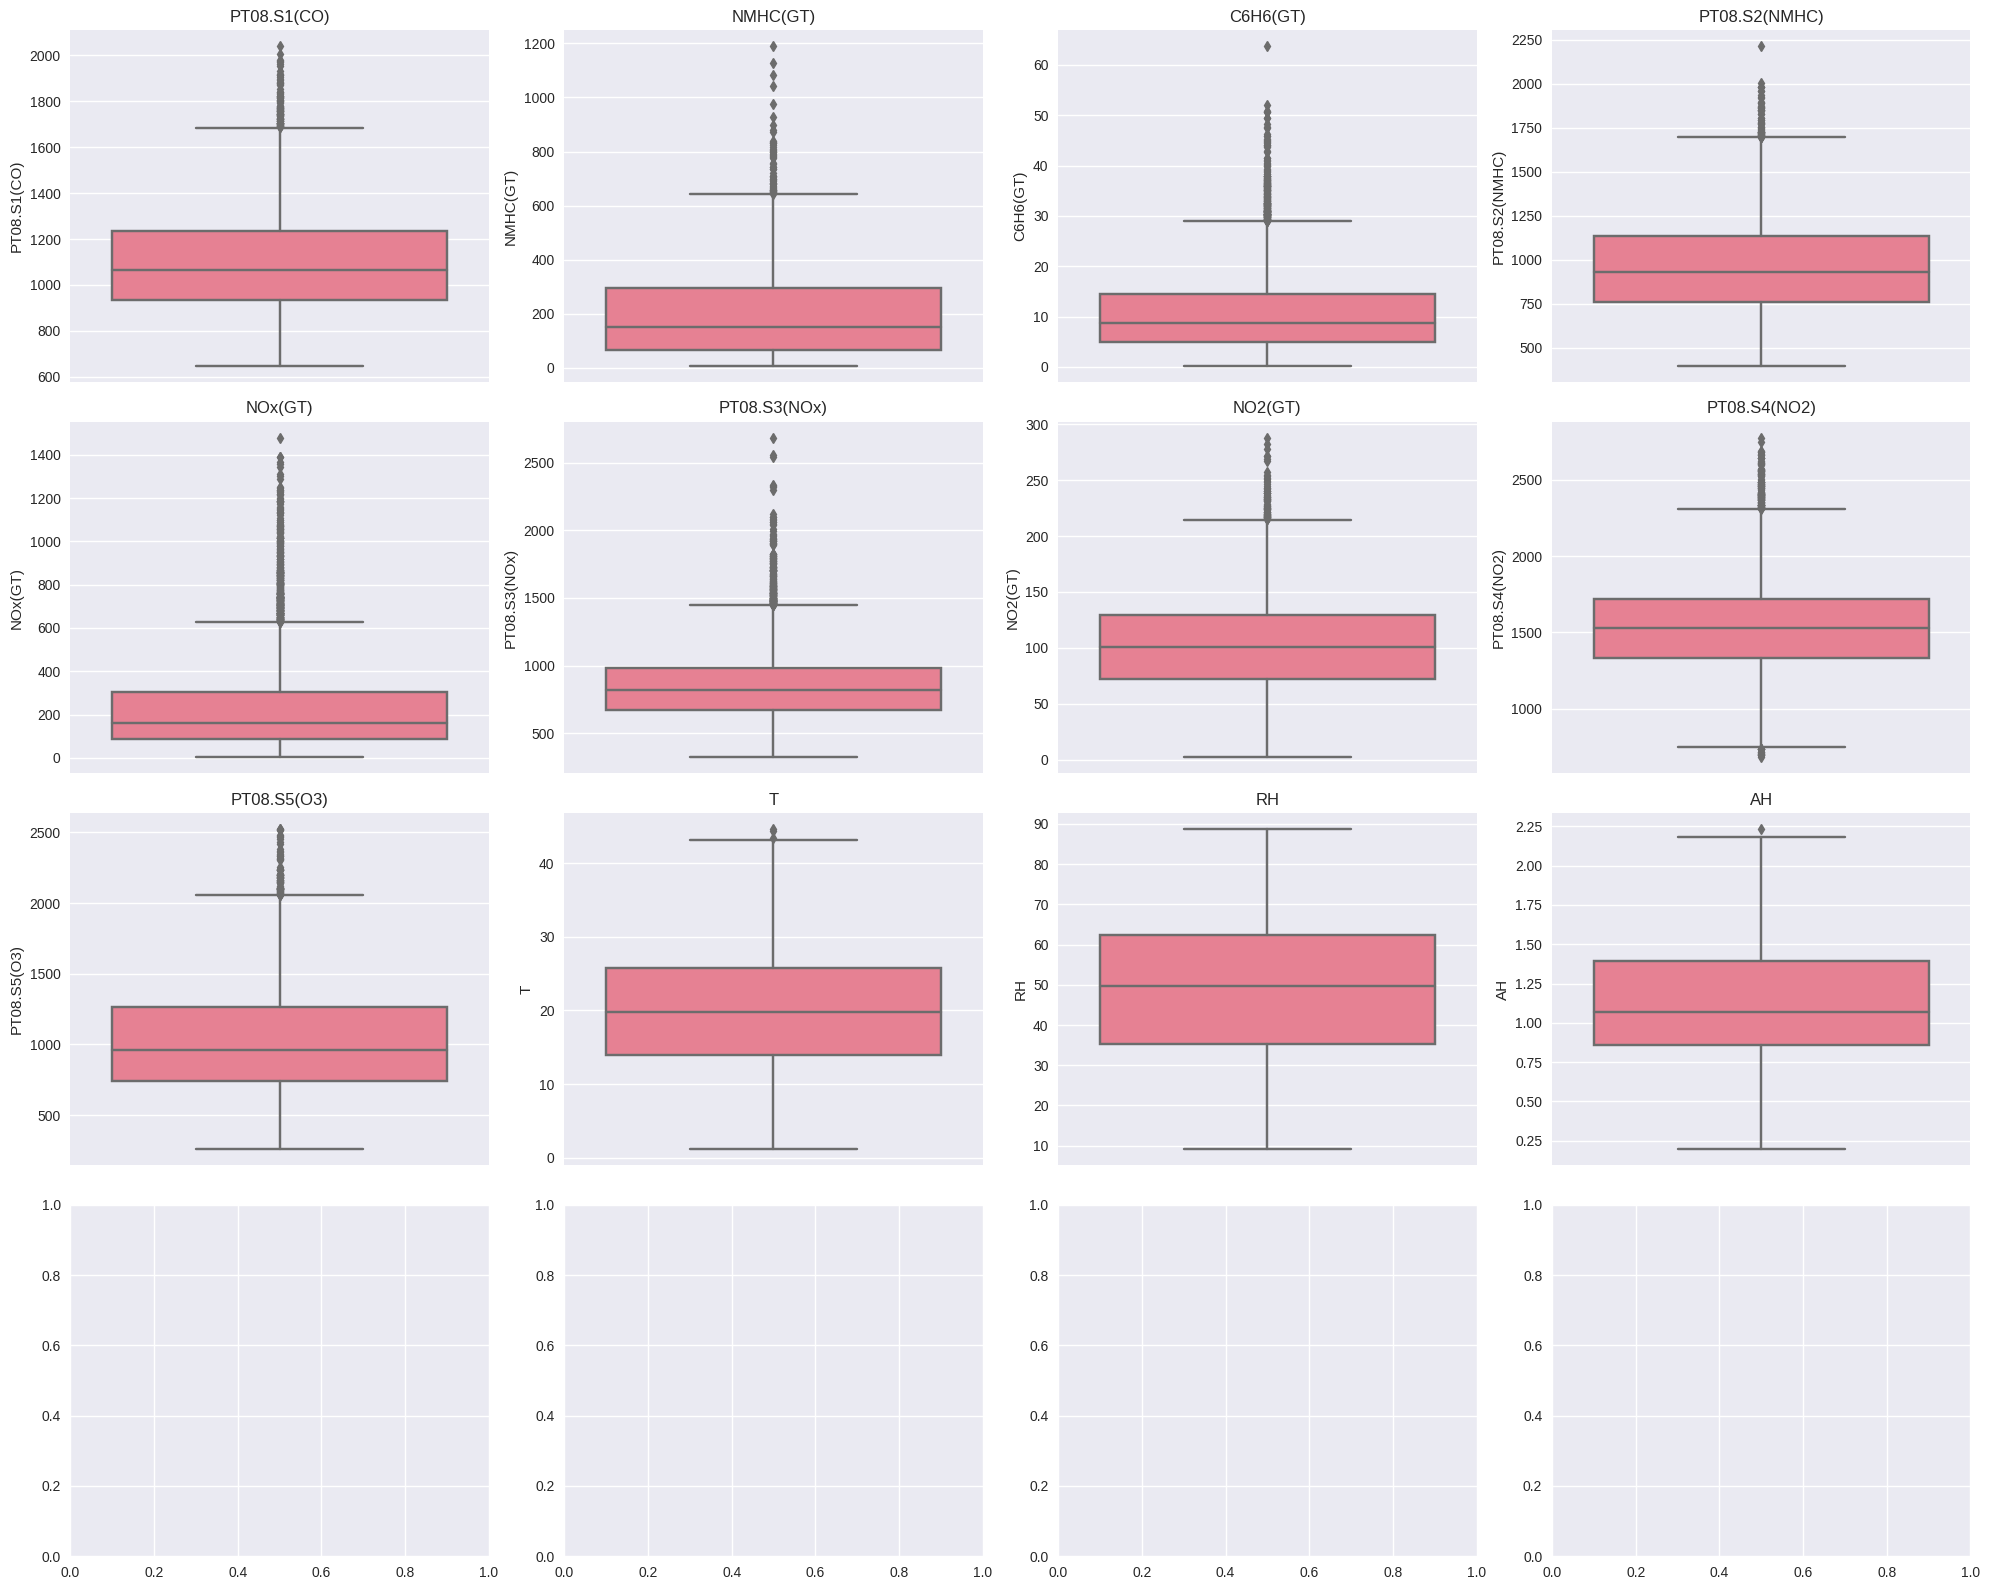

In [8]:
# Visualize Feature Distributions and Correlations
# Select numerical columns
numerical_cols = X_train.select_dtypes(include=[np.number]).columns

# Histograms
fig, axes = plt.subplots(4, 4, figsize=(20, 16))
for i, col in enumerate(numerical_cols):
    if i < 16:
        ax = axes[i//4, i%4]
        X_train[col].hist(bins=50, ax=ax)
        ax.set_title(col)
plt.tight_layout()
plt.show()

# Correlation heatmap
plt.figure(figsize=(12, 10))
corr_matrix = X_train[numerical_cols].corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.show()

# Boxplots for outliers
fig, axes = plt.subplots(4, 4, figsize=(20, 16))
for i, col in enumerate(numerical_cols):
    if i < 16:
        ax = axes[i//4, i%4]
        sns.boxplot(y=X_train[col], ax=ax)
        ax.set_title(col)
plt.tight_layout()
plt.show()

Feature skewness:
PT08.S1(CO)      0.746395
NMHC(GT)         1.554461
C6H6(GT)         1.337654
PT08.S2(NMHC)    0.548090
NOx(GT)          1.891742
PT08.S3(NOx)     1.137541
NO2(GT)          0.508541
PT08.S4(NO2)     0.310843
PT08.S5(O3)      0.665851
T                0.300508
RH              -0.065641
AH               0.217544
dtype: float64


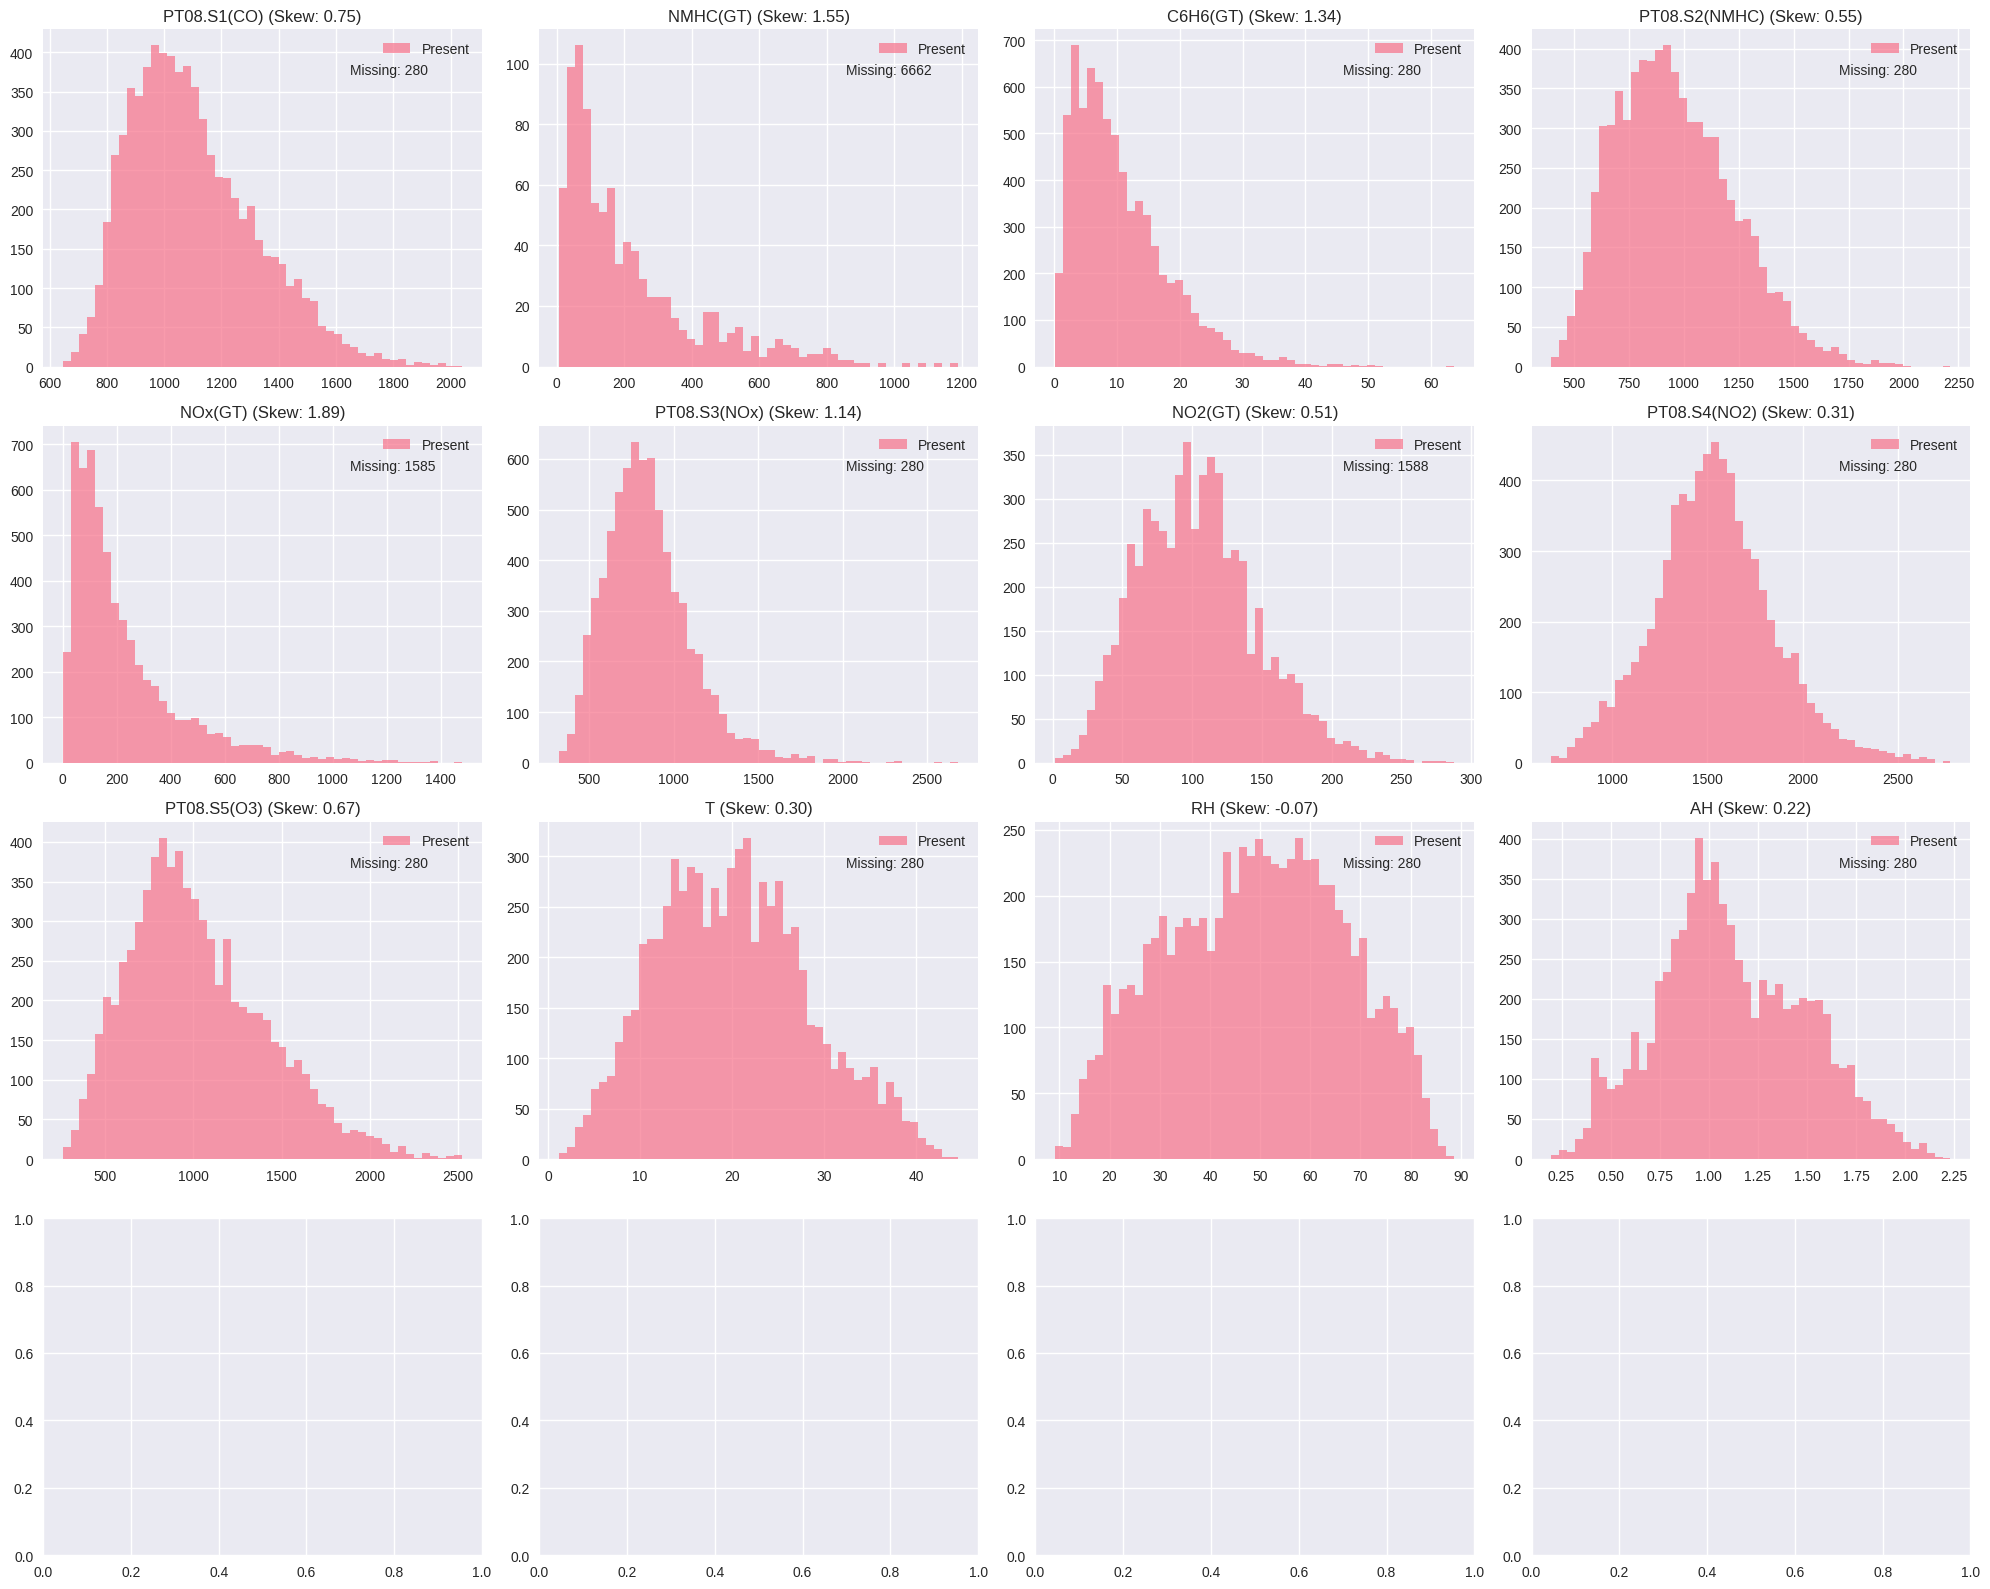

In [9]:
# Analyze Feature Distributions for Imputation Strategy
# Check skewness and decide between mean vs median imputation
from scipy.stats import skew

skewness = X_train[numerical_cols].apply(lambda x: skew(x.dropna()))
print("Feature skewness:")
print(skewness)

# Plot distributions with missing values
fig, axes = plt.subplots(4, 4, figsize=(20, 16))
for i, col in enumerate(numerical_cols):
    if i < 16:
        ax = axes[i//4, i%4]
        # Plot non-missing values
        data = X_train[col].dropna()
        ax.hist(data, bins=50, alpha=0.7, label='Present')
        # Indicate missing values
        missing_count = X_train[col].isnull().sum()
        ax.text(0.7, 0.9, f'Missing: {missing_count}', transform=ax.transAxes, fontsize=10, verticalalignment='top')
        ax.set_title(f'{col} (Skew: {skewness[col]:.2f})')
        ax.legend()
plt.tight_layout()
plt.show()

# Based on skewness and outliers, median imputation is appropriate for skewed distributions

In [10]:
# Analyze Data Types, Missing Values, and Feature Characteristics for Feature Selection
# This analysis will guide feature selection and imputation strategy

# Get total number of samples
total_samples_train = len(X_train)
total_samples_test = len(X_test)

print("="*80)
print("TRAINING SET ANALYSIS")
print("="*80)
print(f"Total samples in training set: {total_samples_train}\n")

# Create a detailed analysis DataFrame
analysis_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Data Type': X_train.dtypes.values,
    'Missing Count': X_train.isnull().sum().values,
    'Missing Percentage': (X_train.isnull().sum().values / total_samples_train * 100).round(2),
    'Non-Missing Count': X_train.count().values,
    'Unique Values': [X_train[col].nunique() for col in X_train.columns]
})

# Sort by missing percentage descending
analysis_df = analysis_df.sort_values('Missing Percentage', ascending=False)

print(analysis_df.to_string(index=False))

print("\n" + "="*80)
print("TEST SET ANALYSIS")
print("="*80)
print(f"Total samples in test set: {total_samples_test}\n")

# Similar analysis for test set
analysis_df_test = pd.DataFrame({
    'Feature': X_test.columns,
    'Data Type': X_test.dtypes.values,
    'Missing Count': X_test.isnull().sum().values,
    'Missing Percentage': (X_test.isnull().sum().values / total_samples_test * 100).round(2),
    'Non-Missing Count': X_test.count().values,
    'Unique Values': [X_test[col].nunique() for col in X_test.columns]
})

analysis_df_test = analysis_df_test.sort_values('Missing Percentage', ascending=False)

print(analysis_df_test.to_string(index=False))

# Summary statistics
print("\n" + "="*80)
print("SUMMARY STATISTICS FOR FEATURE SELECTION")
print("="*80)
print(f"Completely missing features (>80% missing): {(analysis_df['Missing Percentage'] > 80).sum()}")
print(f"High missing rate features (50-80% missing): {((analysis_df['Missing Percentage'] >= 50) & (analysis_df['Missing Percentage'] <= 80)).sum()}")
print(f"Moderate missing rate features (20-50% missing): {((analysis_df['Missing Percentage'] >= 20) & (analysis_df['Missing Percentage'] < 50)).sum()}")
print(f"Low missing rate features (<20% missing): {(analysis_df['Missing Percentage'] < 20).sum()}")
print("\nRecommendation: Consider dropping features with >80% missing values, use median imputation for others.")

TRAINING SET ANALYSIS
Total samples in training set: 7576

      Feature Data Type  Missing Count  Missing Percentage  Non-Missing Count  Unique Values
     NMHC(GT)   float64           6662               87.94                914            429
      NO2(GT)   float64           1588               20.96               5988            249
      NOx(GT)   float64           1585               20.92               5991            863
  PT08.S1(CO)   float64            280                3.70               7296           1025
     C6H6(GT)   float64            280                3.70               7296            403
PT08.S2(NMHC)   float64            280                3.70               7296           1201
 PT08.S3(NOx)   float64            280                3.70               7296           1181
 PT08.S4(NO2)   float64            280                3.70               7296           1472
  PT08.S5(O3)   float64            280                3.70               7296           1638
           

TARGET VARIABLE ANALYSIS: CO(GT) - Carbon Monoxide Levels

Descriptive Statistics for CO(GT):
  Count:       5977
  Mean:        2.21 µg/m³
  Median:      1.90 µg/m³
  Std Dev:     1.48 µg/m³
  Min:         0.10 µg/m³
  Max:         11.90 µg/m³

Quantile Analysis (Base for Threshold Definition):
  25th Percentile (Q1): 1.10 µg/m³
  50th Percentile (Q2): 1.90 µg/m³
  75th Percentile (Q3): 3.00 µg/m³

Tertile Analysis (33.33% split):
  33rd Percentile:     1.40 µg/m³
  67th Percentile:     2.50 µg/m³


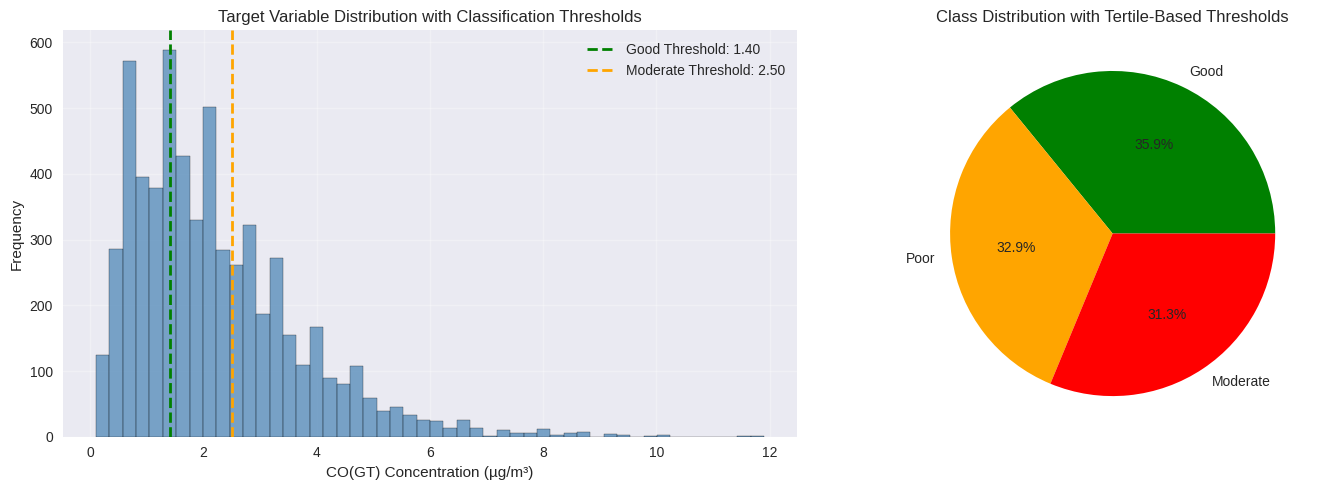


CLASSIFICATION THRESHOLD LOGIC - RECOMMENDATION

Approach 1: QUANTILE-BASED THRESHOLDS (Data-Driven) ✓ RECOMMENDED
  • Good Air Quality:      CO(GT) ≤ 1.40 µg/m³ (2145 samples: 28.3%)
  • Moderate Air Quality:  1.40 < CO(GT) ≤ 2.50 µg/m³ (1868 samples: 24.7%)
  • Poor Air Quality:      CO(GT) > 2.50 µg/m³ (1964 samples: 25.9%)

  Advantages:
    - Balanced class distribution (3-way split)
    - Data-driven approach based on actual CO levels
    - Avoids class imbalance problems in model training
    - Reflects natural patterns in the dataset

Approach 2: WHO/EPA-BASED THRESHOLDS (Domain Standards)
  • Good:      CO(GT) ≤ 1.0 mg/m³  (WHO safe limit)
  • Moderate:  1.0 < CO(GT) ≤ 3.0 mg/m³
  • Poor:      CO(GT) > 3.0 mg/m³

  Note: Requires mapping µg/m³ to mg/m³ and may lead to imbalanced classes

FINAL DECISION FOR AIRFLOW PIPELINE
✓ Use QUANTILE-BASED THRESHOLDS (Tertile Split):
  - Threshold 1 (Good->Moderate): 1.40 µg/m³
  - Threshold 2 (Moderate->Poor):  2.50 µg/m³

✓ Implementati

In [11]:
# Target Variable Analysis & Classification Threshold Definition
# Convert Regression Problem to Classification Problem (Good, Moderate, Poor Air Quality)

print("="*80)
print("TARGET VARIABLE ANALYSIS: CO(GT) - Carbon Monoxide Levels")
print("="*80)

# Statistical Summary
print("\nDescriptive Statistics for CO(GT):")
print(f"  Count:       {y_train.count()}")
print(f"  Mean:        {y_train.mean():.2f} µg/m³")
print(f"  Median:      {y_train.median():.2f} µg/m³")
print(f"  Std Dev:     {y_train.std():.2f} µg/m³")
print(f"  Min:         {y_train.min():.2f} µg/m³")
print(f"  Max:         {y_train.max():.2f} µg/m³")

# Quartile Analysis
print("\nQuantile Analysis (Base for Threshold Definition):")
q25 = y_train.quantile(0.25)
q50 = y_train.quantile(0.50)  # Median
q75 = y_train.quantile(0.75)

print(f"  25th Percentile (Q1): {q25:.2f} µg/m³")
print(f"  50th Percentile (Q2): {q50:.2f} µg/m³")
print(f"  75th Percentile (Q3): {q75:.2f} µg/m³")

# Tertile Analysis - For balanced 3-class distribution
tertile_33 = y_train.quantile(0.33)
tertile_67 = y_train.quantile(0.67)

print(f"\nTertile Analysis (33.33% split):")
print(f"  33rd Percentile:     {tertile_33:.2f} µg/m³")
print(f"  67th Percentile:     {tertile_67:.2f} µg/m³")

# Visualize Distribution with Thresholds
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram with tertile thresholds
axes[0].hist(y_train, bins=50, alpha=0.7, color='steelblue', edgecolor='black')
axes[0].axvline(tertile_33, color='green', linestyle='--', linewidth=2, label=f'Good Threshold: {tertile_33:.2f}')
axes[0].axvline(tertile_67, color='orange', linestyle='--', linewidth=2, label=f'Moderate Threshold: {tertile_67:.2f}')
axes[0].set_xlabel('CO(GT) Concentration (µg/m³)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Target Variable Distribution with Classification Thresholds')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Pie chart showing class distribution
class_distribution = pd.cut(y_train, bins=[y_train.min()-1, tertile_33, tertile_67, y_train.max()+1], 
                             labels=['Good', 'Moderate', 'Poor'])
class_counts = class_distribution.value_counts()
axes[1].pie(class_counts, labels=class_counts.index, autopct='%1.1f%%', colors=['green', 'orange', 'red'])
axes[1].set_title('Class Distribution with Tertile-Based Thresholds')

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("CLASSIFICATION THRESHOLD LOGIC - RECOMMENDATION")
print("="*80)

print("\nApproach 1: QUANTILE-BASED THRESHOLDS (Data-Driven) ✓ RECOMMENDED")
print(f"  • Good Air Quality:      CO(GT) ≤ {tertile_33:.2f} µg/m³ ({(class_distribution == 'Good').sum()} samples: {(class_distribution == 'Good').sum()/len(y_train)*100:.1f}%)")
print(f"  • Moderate Air Quality:  {tertile_33:.2f} < CO(GT) ≤ {tertile_67:.2f} µg/m³ ({(class_distribution == 'Moderate').sum()} samples: {(class_distribution == 'Moderate').sum()/len(y_train)*100:.1f}%)")
print(f"  • Poor Air Quality:      CO(GT) > {tertile_67:.2f} µg/m³ ({(class_distribution == 'Poor').sum()} samples: {(class_distribution == 'Poor').sum()/len(y_train)*100:.1f}%)")

print("\n  Advantages:")
print("    - Balanced class distribution (3-way split)")
print("    - Data-driven approach based on actual CO levels")
print("    - Avoids class imbalance problems in model training")
print("    - Reflects natural patterns in the dataset")

print("\nApproach 2: WHO/EPA-BASED THRESHOLDS (Domain Standards)")
print("  • Good:      CO(GT) ≤ 1.0 mg/m³  (WHO safe limit)")
print("  • Moderate:  1.0 < CO(GT) ≤ 3.0 mg/m³")
print("  • Poor:      CO(GT) > 3.0 mg/m³")
print("\n  Note: Requires mapping µg/m³ to mg/m³ and may lead to imbalanced classes")

print("\n" + "="*80)
print("FINAL DECISION FOR AIRFLOW PIPELINE")
print("="*80)
print(f"✓ Use QUANTILE-BASED THRESHOLDS (Tertile Split):")
print(f"  - Threshold 1 (Good->Moderate): {tertile_33:.2f} µg/m³")
print(f"  - Threshold 2 (Moderate->Poor):  {tertile_67:.2f} µg/m³")
print(f"\n✓ Implementation: Use pd.cut() in Airflow preprocessing task")
print(f"✓ Class Distribution: ~33% Good, ~34% Moderate, ~33% Poor (Balanced)")

In [13]:
# Convert Target Variable to Classification Labels and Save Combined Dataset for Airflow Pipeline
# Save the full dataset with classification labels to data/raw/data.csv for Airflow to load and split.

print("="*80)
print("CONVERTING TARGET VARIABLE TO CLASSIFICATION LABELS")
print("="*80)

# Use the quantile-based thresholds defined earlier in the notebook
tertile_33 = y_train.quantile(0.33)
tertile_67 = y_train.quantile(0.67)

print(f"Using thresholds:\n  Good <= {tertile_33:.2f}\n  Moderate <= {tertile_67:.2f}\n  Poor > {tertile_67:.2f}\n")

# Convert target values to class labels for the full dataset
full_target_labels = pd.cut(
    y,
    bins=[y.min() - 1, tertile_33, tertile_67, y.max() + 1],
    labels=['Good', 'Moderate', 'Poor']
)

print("Full dataset label distribution:")
print(full_target_labels.value_counts())

# Combine features with classification labels
full_dataset = X.copy()
full_dataset['Target'] = full_target_labels

# Save the combined dataset to data/raw/data.csv for Airflow pipeline
full_dataset.to_csv('data/raw/data.csv', index=False)

print("\nSaved combined dataset:")
print("  - data/raw/data.csv (features + classification labels)")
print("\nNote: Airflow pipeline will load this dataset, split into train/test, and perform preprocessing.")

CONVERTING TARGET VARIABLE TO CLASSIFICATION LABELS
Using thresholds:
  Good <= 1.40
  Moderate <= 2.50
  Poor > 2.50

Full dataset label distribution:
CO(GT)
Good        2902
Poor        2393
Moderate    2379
Name: count, dtype: int64

Saved combined dataset:
  - data/raw/data.csv (features + classification labels)

Note: Airflow pipeline will load this dataset, split into train/test, and perform preprocessing.


# EDA Findings & Apache Airflow Orchestration Strategy

## Key EDA Findings

### 1. Dataset Overview
- **Total Samples**: 11690 records
- **Target Variable**: CO(GT) - Predicting carbon monoxide levels (NOW CLASSIFICATION with 3 classes)
- **Dataset Location**: data/raw/data.csv (features + classification labels)

### 2. Feature Analysis & Missing Data Insights

#### High Missing Rate Features (>80% - TO BE DROPPED):
- **NMHC(GT)**: >80% missing values → **DROP from features**

#### Other Features:
- Most numerical features have low to moderate missing values (<50%)
- Missing values show varying patterns - median imputation identified as optimal strategy
- Data is heavily skewed in several features

### 3. Data Quality Issues Identified
- Multiple features exhibit right-skewed distributions with outliers
- Presence of missing values denoted as -200 in raw data
- Several sensor readings (PT08.S1, PT08.S2, etc.) show high variability

### 4. Feature Characteristics
- All features are **numerical** - no categorical encoding required
- Strong correlations exist between some pollution-related features
- Temperature (T), Relative Humidity (RH), and Absolute Humidity (AH) show distinct patterns

### 5. Target Variable Classification
- **Converted CO(GT) from Regression to Classification**
- **3-Class Problem**: Good, Moderate, Poor (Air Quality Classes)
- **Thresholds**: Quantile-based (tertile split) for balanced class distribution
- **Label Encoding**: Good=0, Moderate=1, Poor=2 (done in Airflow)

---

## Apache Airflow DAG Tasks - Orchestration Plan

### Task 1: Data Ingestion
```
Load combined dataset from data/raw/data.csv
- Dataset already contains classification labels ('Good', 'Moderate', 'Poor')
- Apply parsers if needed: sep=',', na_values=-200
- Output: Full dataframe with features and classification labels
- DVC: Version raw dataset
```

### Task 2: Train-Test Split
```
- Split data 80-20 (no shuffle - preserve temporal order for time series)
- Random state: 42 (for reproducibility)
- Output: X_train, X_test, y_train_class, y_test_class (classification labels)
- NOTE: Test set is held back for drift detection and retraining
- DVC: Version train/test split indices
```

### Task 3: Feature Selection & Dropping
```
- DROP HIGH MISSING FEATURES:
  - NMHC(GT) - >80% missing

- KEEP all other numerical features
- Output: Cleaned feature set with selected columns only
- Apply to TRAIN data only
```

### Task 4: Label Encoding
```
- Apply Label Encoding to TRAIN classification labels:
  • 'Good' → 0
  • 'Moderate' → 1
  • 'Poor' → 2
- Output: y_train_encoded (numeric labels)
- Save label mapping to: data/processed/label_mapping.csv
- NOTE: Test labels remain as strings for future drift detection
```

### Task 5: Preprocessing Pipeline Creation
```
Numerical Feature Pipeline:
- Step 1: Imputation - SimpleImputer(strategy='median')
  - Reason: Data is skewed; median handles outliers better than mean
- Step 2: Scaling - StandardScaler()
  - Reason: Features have different scales; scale to mean=0, std=1

No Categorical Encoding Needed:
- All features are numerical
```

### Task 6: Fit Preprocessor on Training Data
```
- Fit fitted_preprocessor on X_train only
- Learn imputation values (medians) and scaling parameters
- Save fitted_preprocessor object: artifacts/preprocessor.joblib
- Save baseline statistics for drift detection: artifacts/baseline_stats.pkl
- DVC: Version preprocessor artifacts
```

### Task 7: Transform Training Data
```
- Apply fitted_preprocessor to X_train → X_train_processed
- Verify shapes and consistency
- Save processed training dataset:
  • data/processed/train_processed.csv (features + encoded target)
- NOTE: Test data is NOT processed yet - saved for future drift monitoring
- DVC: Version processed training data
```

### Task 8: Feature Engineering (Optional)
```
- Extract temporal features from Date/Time (hour, day, month, year)
- Create lag features for time series (if needed for modeling)
- Create interaction features (temperature × humidity, etc.)
- Apply to processed training data only
```

### Task 9: Artifact Persistence
```
Save for production pipeline:
- artifacts/preprocessor.joblib - Fitted scaler & imputer
- artifacts/feature_names.txt - Column names (for reuse)
- artifacts/train_indices.pkl - Training data indices
- data/processed/label_mapping.csv - Target label encoding mapping
- artifacts/baseline_stats.pkl - Baseline statistics for drift detection
- Config file with all preprocessing parameters
- DVC: Version all artifacts
```

### Task 10: Model Training (MLflow Integration)
```
- Load X_train_processed and y_train_encoded
- Train classification model (e.g., XGBoost, Random Forest, Logistic Regression)
- Perform hyperparameter tuning with cross-validation
- MLflow: Log hyperparameters, metrics, and model artifacts
- Save best model to MLflow Model Registry
- Problem Type: 3-class Classification (Multi-class)
- NOTE: No initial evaluation - test data is held for production monitoring
```

### Task 11: Model Deployment (FastAPI + Docker)
```
- Load best model from MLflow Registry
- Create FastAPI inference service with preprocessing pipeline
- Implement /predict endpoint with input validation
- Docker: Containerize FastAPI app
- Deploy to production environment
- Set up monitoring for data drift and model performance
- NOTE: Test data remains untouched for future drift detection
```

### Task 12: Drift Detection & Retraining (Triggered by New Data)
```
- When new data arrives (simulated by test set):
  • Load test data: X_test, y_test_class
  • Apply feature selection (drop NMHC)
  • Check for data drift using baseline statistics (KS test, PSI)
  • MLflow: Log drift metrics
  • If drift detected above threshold:
    • Retrain model with combined train + new data
    • Update preprocessor and model artifacts
    • Redeploy updated model via FastAPI
    • DVC: Version new datasets and artifacts
- Trigger: Scheduled or event-based (new data arrival)
```

### Task 13: Frontend Integration (Streamlit/React)
```
- Build web interface for model predictions
- Connect to FastAPI backend via REST API
- Display air quality predictions with confidence scores
- Show historical predictions and drift alerts
- Docker: Containerize frontend application
```

### Task 14: Monitoring & Alerting (Prometheus + Grafana)
```
- Instrument FastAPI with Prometheus client
- Track inference latency, error rates, drift scores
- Grafana: Create dashboards for real-time monitoring
- Set up alerts for:
  • High error rates (>5%)
  • Significant data drift
  • Model performance degradation
```

---

## Implementation Notes for Airflow

1. **Dependency Chain**: Task→Task dependency to ensure sequential execution
2. **Sensor Tasks**: Monitor data availability in data/raw/ before ingestion
3. **Conditional Tasks**: Branch based on data quality checks and drift detection
4. **Error Handling**: Retry logic for failed tasks with exponential backoff
5. **Logging**: Comprehensive logging for audit trail and debugging
6. **Idempotency**: Each task should be idempotent (safe to rerun)
7. **Parameters**: Externalize thresholds (e.g., missing value thresholds, test size, quantile values, drift thresholds) to DAG config
8. **Testing**: Unit tests for each preprocessing step before production deployment
9. **Drift Monitoring**: Implement statistical tests (KS test, PSI) for feature drift detection
10. **Retraining Strategy**: Incremental learning or full retraining based on drift severity
11. **Data Versioning**: Use DVC to track dataset versions for reproducible retraining
12. **Experiment Tracking**: MLflow for model versioning and comparison
13. **Containerization**: Docker for reproducible deployments across environments
14. **Orchestration**: Docker Compose for local development ecosystem (Airflow + MLflow + Grafana + Frontend)